In [85]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/EDA_zadanie") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

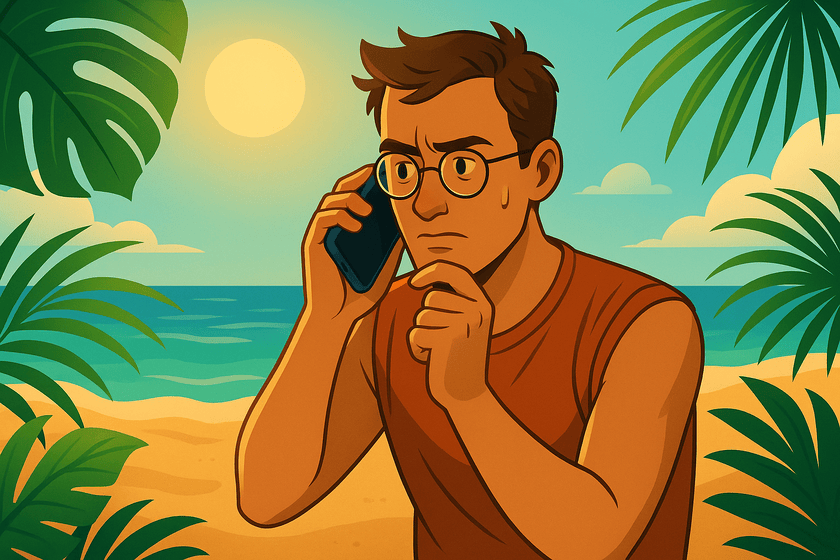

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [87]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
titanic_df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S


In [88]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [89]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [90]:
titanic_df.describe(include='all')



,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


Zmienna `Survived` oznacza predykowaną klase.

### Czy wszystkie kolumny są istotne?
1. `Ticket` - ciąg znaków, który nie wnosi informacji. Usuwam.
2. `Name` - samo imię nie ma znaczenia, ale tytuły takie jak Mr., Mrs., Miss. mogą nieść dodatkowe informacje o osobie, więc warto je zapisać do nowej kolumny `Title`.
3. `Cabin` - tylko pierwsza litera jest ważna, bo mówi o sekcji/regionie statku, w którym znajodwała się kabina pasażera. Będę ją przechowywał w kolumnie `Deck` (ang. pokład/nr pokładu).
4. `Fare`, `Embarked` - określiłbym je jako zmienne z potencjałem, bo mogą wskazywać na klasę społeczną czy coś. Zostawiam.

In [91]:

titanic_df = titanic_df.drop(columns=['Ticket'])

In [92]:
def get_title(name):
    for word in name.split(" "):
        if word.endswith("."):
            return word[:-1]
    return None

titanic_df['Title'] = titanic_df['Name'].apply(get_title)

titanic_df = titanic_df.drop(columns=['Name'])

In [93]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df = titanic_df.drop(columns=['Cabin'])

In [94]:
titanic_df.head(15)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Deck
PassengerId,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,Mr,NaN
2,1,1,female,38.0,1,0,71.2833,C,Mrs,C
3,1,3,female,26.0,0,0,7.9250,S,Miss,NaN
4,1,1,female,35.0,1,0,53.1000,S,Mrs,C
5,0,3,male,35.0,0,0,8.0500,S,Mr,NaN
6,0,3,male,NaN,0,0,8.4583,Q,Mr,NaN
7,0,1,male,54.0,0,0,51.8625,S,Mr,E
8,0,3,male,2.0,3,1,21.0750,S,Master,NaN
9,1,3,female,27.0,0,2,NaN,S,Mrs,NaN


In [95]:
def get_percentage_missing(df, axis):
  """
    Zwraca procent brakujących wartości (NaN) w wierszach lub kolumnach DataFrame.

    df : pandas.DataFrame
        Tabela danych, dla której liczone są braki.

    axis : int
        Oś, względem której obliczane są braki:
        - 0 : procent braków w każdej kolumnie
        - 1 : procent braków w każdym wierszu
  """
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

get_percentage_missing(titanic_df, 0)

,0
Age,19.87
Fare,11.00
Embarked,0.22
Deck,77.10


### Analiza outlier'ów
Żeby zdecydować, co zrobic z brakującymi wartościami warto przeanalizować wartości skrajne.

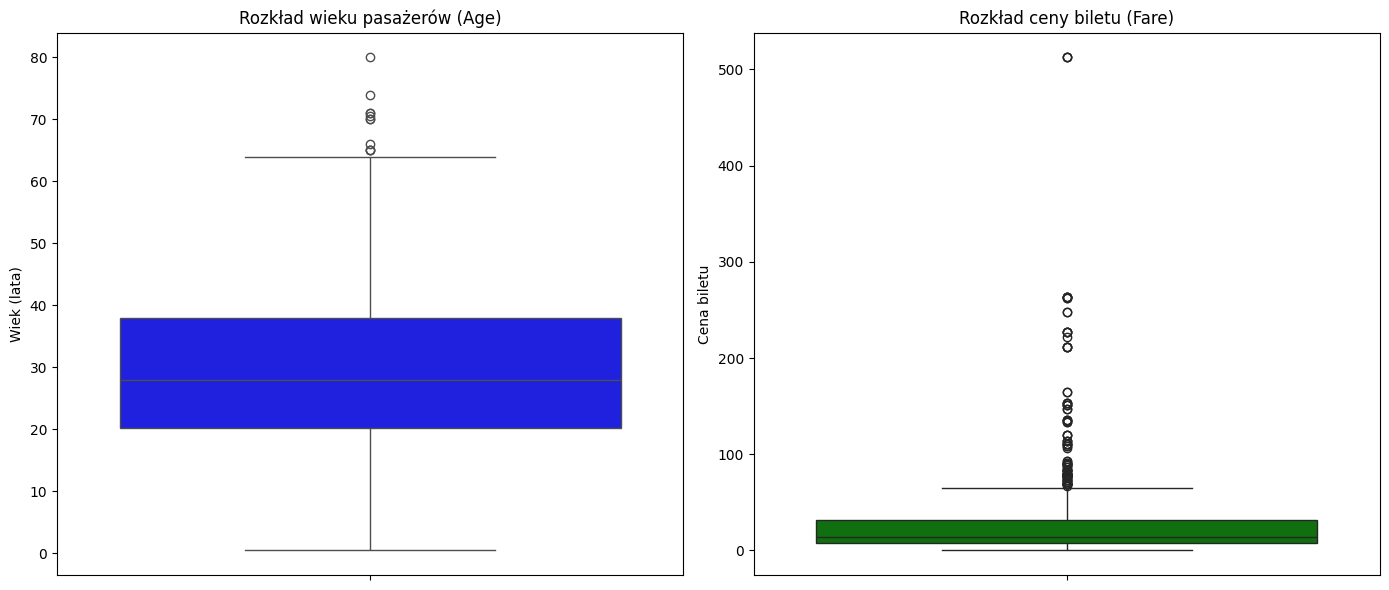

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

# miejsce na dwa wykresy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# wykres Age
sns.boxplot(data=titanic_df, y='Age', ax=axes[0], color='blue')
axes[0].set_title('Rozkład wieku pasażerów (Age)')
axes[0].set_ylabel('Wiek (lata)')

# wykres Fare
sns.boxplot(data=titanic_df, y='Fare', ax=axes[1], color='green')
axes[1].set_title('Rozkład ceny biletu (Fare)')
axes[1].set_ylabel('Cena biletu')

# wyświetlenie
plt.tight_layout()
plt.show()


Z wykresów wynika, że wiek pasażerów jest w miarę równo rozłożony ale nadal jest dużo wartości odstaje, a w cenach biletów mamy mnóstwo wartości skrajnych, które mogą zaburzyć obraz (średnią).

Obu przypadkach warto zastąpić wartości puste medianą, aby uniknąć nieproporcjonalnego wpływu z jedenj strony seniorów, a VIP-ów z drugiej.

Co do zmiennych kategorialnych z pustymi wartościami:
1. 'Embarked' ma ich bardzo mało więc można wstawić dominantę w puste miejsca.
2. 'Deck' ma bardzo dużo pustych miejsc a nie można zgadywać ani wyciągać średniej, więc lepiej dodać nową kategorię 'U' (od ang. unknown).

In [97]:
titanic_df['Embarked'].mode()

,Embarked
0,S


In [98]:
# mediany
titanic_df["Age"] = titanic_df.groupby(["Title", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median()) # in case there are only Na values in a group
titanic_df["Fare"] = titanic_df.groupby(["Pclass", "Embarked"])["Fare"].transform(
    lambda x: x.fillna(x.median())
)
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median()) # in case there are only Na values in a group

# dominanta (funkcja mode)
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

# nowy typ U unknown
titanic_df['Deck'] = titanic_df['Deck'].fillna('U')

print(titanic_df.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
Deck        0
dtype: int64


### Typy danych

In [99]:
# Typy danych przed zmianą:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object
Title,object
Deck,object


`Pclass` zostało błędnie potraktowane jako liczba, tak samo jak `Survived`.`

In [100]:

titanic_df['Survived'] = titanic_df['Survived'].astype('category')
titanic_df['Pclass'] = titanic_df['Pclass'].astype('category')

Do tego są kolumny `Sex`, `Embarked`, `Deck` i `Title`; wszystkie przechowują kategorie. Dlatego też warto ustawić je na `category`.

In [101]:
categorical_cols = ['Sex', 'Embarked', 'Deck', 'Title']
for col in categorical_cols:
    titanic_df[col] = titanic_df[col].astype('category')

`category` jasno mówi modelowi że to nie jest dowolny ciąg znaków, tylko jedna z wielu opcji, więc warto tego użyć.

In [102]:
# Typy po zmianie
titanic_df.dtypes

,0
Survived,category
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category
Title,category
Deck,category


### Rozkład zmiennej predykowanej
Zacznijmy od płci i klasy, bo może to mieć duże znaczenie.


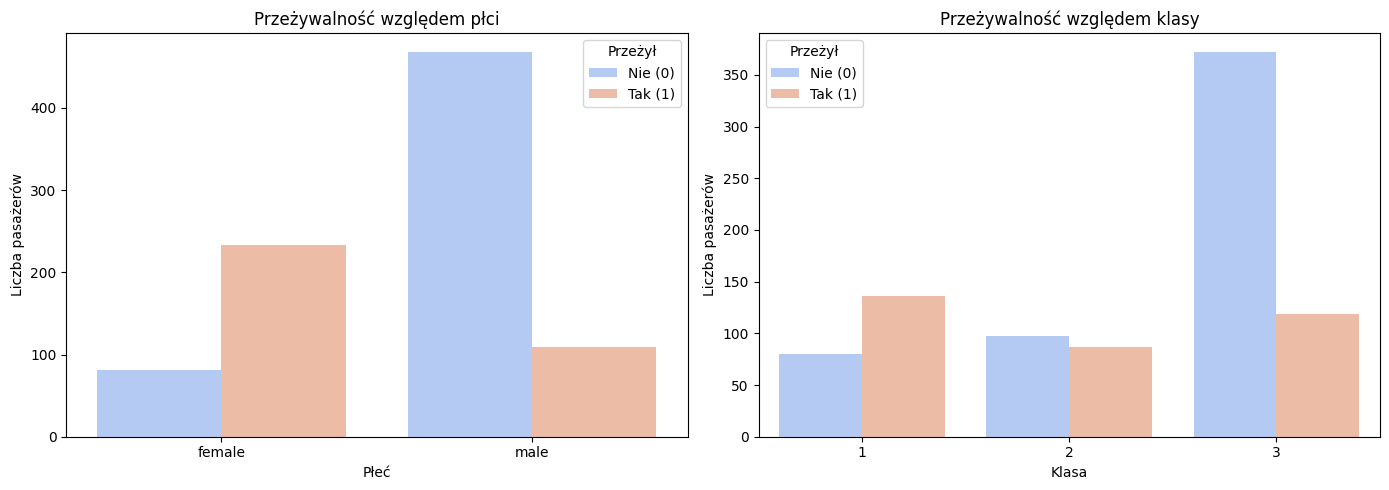

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# przeżywalność a płeć
sns.countplot(data=titanic_df, x='Sex', hue='Survived', ax=axes[0], palette='coolwarm')
axes[0].set_title('Przeżywalność względem płci')
axes[0].set_xlabel('Płeć')
axes[0].set_ylabel('Liczba pasażerów')
axes[0].legend(title='Przeżył', labels=['Nie (0)', 'Tak (1)'])

# przeżywalność a klasa
sns.countplot(data=titanic_df, x='Pclass', hue='Survived', ax=axes[1], palette='coolwarm')
axes[1].set_title('Przeżywalność względem klasy')
axes[1].set_xlabel('Klasa')
axes[1].set_ylabel('Liczba pasażerów')
axes[1].legend(title='Przeżył', labels=['Nie (0)', 'Tak (1)'])

plt.tight_layout()
plt.show()

Kobiety i ludzie z wyższych klas mieli największe szanse na przeżycie.

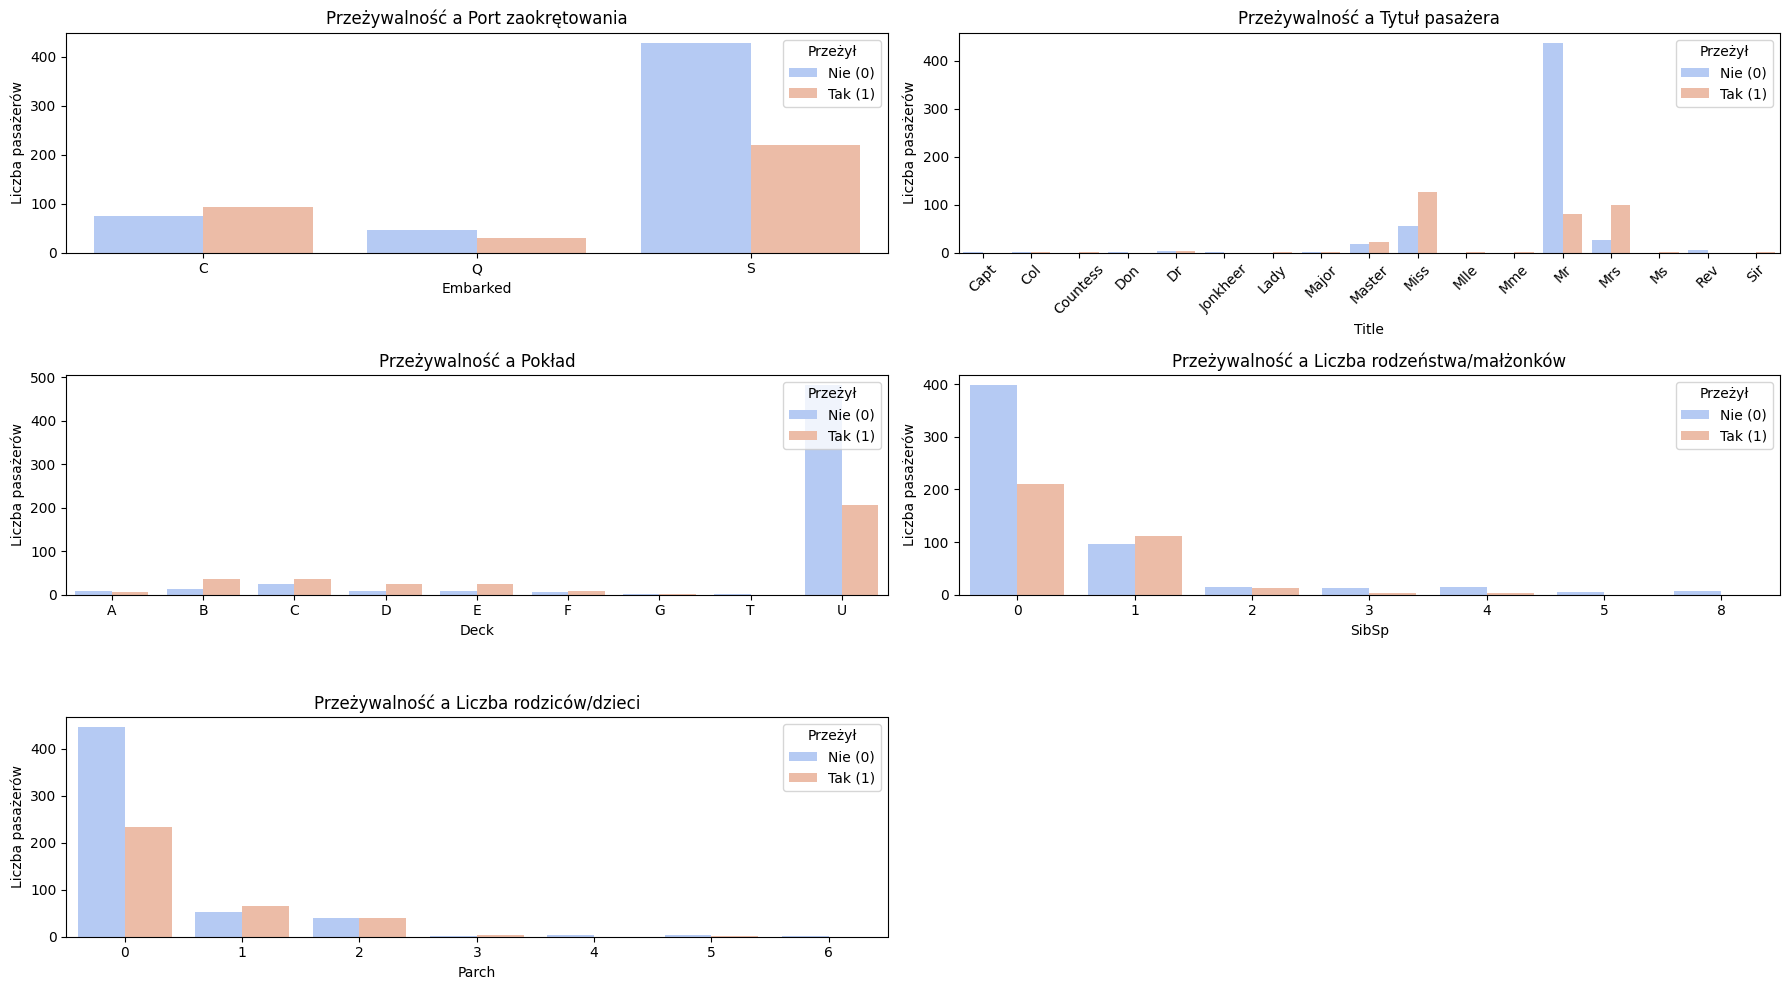

In [104]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
axes = axes.flatten()

# kolumny i tytuły
cols_to_plot = ['Embarked', 'Title', 'Deck', 'SibSp', 'Parch']
plot_titles = ['Port zaokrętowania', 'Tytuł pasażera', 'Pokład',
               'Liczba rodzeństwa/małżonków', 'Liczba rodziców/dzieci']

# generowanie wykresów
for i, col in enumerate(cols_to_plot):
    sns.countplot(data=titanic_df, x=col, hue='Survived', ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Przeżywalność a {plot_titles[i]}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Liczba pasażerów')
    axes[i].legend(title='Przeżył', labels=['Nie (0)', 'Tak (1)'], loc='upper right')

    # tytuły trzeba obrócić bo się nie mieszczą
    if col == 'Title':
        axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Wnioski:
1. **Port (Embarked):** Najwyższa przeżywalność była wśród pasażerów wsiadających w Cherbourgu (C).
2. **Tytuł (Title):** Potwierdza zasadę ratowania kobiet (Miss, Mrs), ale też pokazuje, że chłopcy (tytuł 'Master') mieli znacznie większe szanse na ratunek niż dorośli mężczyźni ('Mr'). Do tego jest wiele mało znaczących tutułów. Miałyby one korelację z przeżywalnością bliską 0. Poniżej zamienie je wszystkie na jedną kategorię `Other`.
3. **Pokład (Deck):** Ci którym przypisano pokład (pewnie te droższe apartamenty) mieli większe szanse na przeżycie niż ci z kategorii `uknownwn`.
4. **Wielkość rodziny (SibSp, Parch):** Co ciekawe im więcej bliskich tym większa szansa na przeżycie. Myślałem, że może właśnie potrzeba dbania o bliskich, by przeszkadzała, ale okazuje się że w kupie siła. Moja obawa jednak jest prawdziwa dla tych którzy mieli >=3 rodzeństwa/małżonków - dla nich przeżhwalność bardzo spadała, czyli zależność nie jest liniowa. Warto zostawić to jako liczbę.

In [105]:
rare_titles = ['Don', 'Rev', 'Dr', 'Mme', 'Ms', 'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess', 'Jonkheer']
# zamieniam na string i spowrotem na category bo inaczej wyświetla się FutureWarning
titanic_df['Title'] = titanic_df['Title'].astype(str)

titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Other')

titanic_df['Title'] = titanic_df['Title'].astype('category')

titanic_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Other,27


Zastanawiałem się czy skoro mamy tytuły określające płeć i wiek, to nie możnaby wyczyścić nieco dane usuwając całkiem kolumne `Sex`, ale zdecydowałem się ją zostawić ze względu na kategorię `Other` - dla tych 27 osób dana o płci będzie ważna.

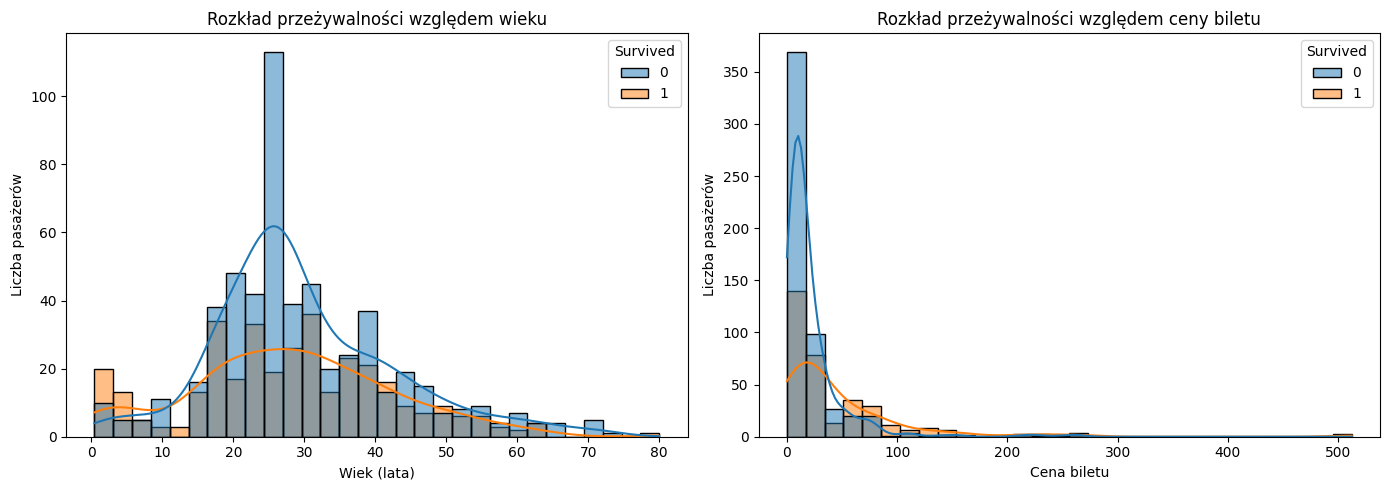

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram dla wieku
sns.histplot(data=titanic_df, x='Age', hue='Survived', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Rozkład przeżywalności względem wieku')
axes[0].set_xlabel('Wiek (lata)')
axes[0].set_ylabel('Liczba pasażerów')

# histogram dla ceny biletu
sns.histplot(data=titanic_df, x='Fare', hue='Survived', ax=axes[1], kde=True, bins=30)
axes[1].set_title('Rozkład przeżywalności względem ceny biletu')
axes[1].set_xlabel('Cena biletu')
axes[1].set_ylabel('Liczba pasażerów')

plt.tight_layout()
plt.show()

### Wnioski z wieku i ceny biletu
1. **Wiek (Age):** Dzieci do około 10 lat miały największe szanse na przeżycie. Dużo danych około 28-29 lat to efekt uzupełnienia pustych danch medianą. Poza tym rozkład nieco przypomina normalny (z wyjątkiem skrajnej lewej strony).
2. **Cena biletu (Fare):** Im droższy bilet tym większa szansa na przeżycie (pewnie ze względu na status majątkowy i zakwaterowanie). Rozkład bardzo asymetryczny.

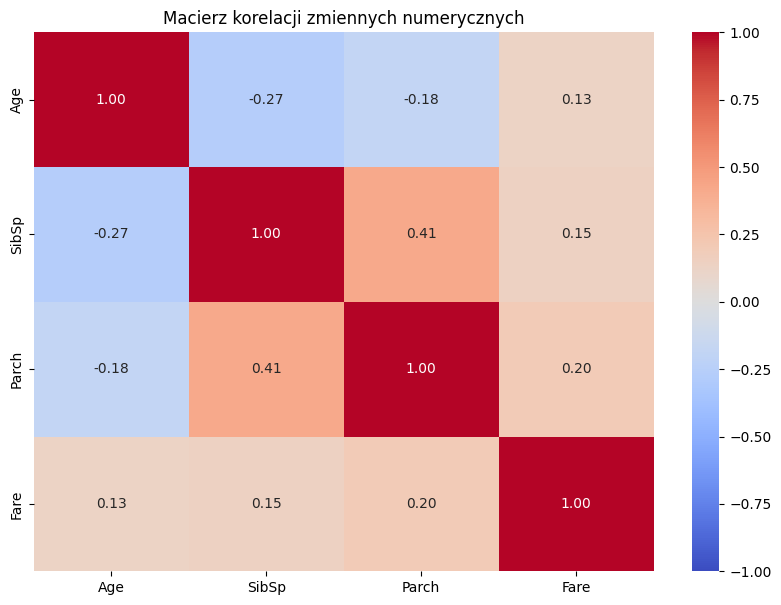

In [107]:
def draw_numeric_heatmap():
  plt.figure(figsize=(10, 7))

  numeric_cols = titanic_df.select_dtypes(include=['number']).columns
  sns.heatmap(titanic_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
  plt.title("Macierz korelacji zmiennych numerycznych")
  plt.show()

draw_numeric_heatmap()

Widać, że `SibSp` trochę koreluje z `Parch`, oba oznaczają wielkość rodziny. Można zatem je połączyć w jedno `FamiliSize`.

In [108]:
titanic_df['FamilySize'] = titanic_df['Parch'] + titanic_df['SibSp']
titanic_df.drop(columns=['Parch', 'SibSp'], inplace=True)

Heatmapa nie uwzględnia `Pclass` i `Survived`, bo wcześniej zmieniłem ich typ na `category`. Zmienię je spowrotem na `int`, żeby zobaczyć, czy da to jakieś ważne wnioski.

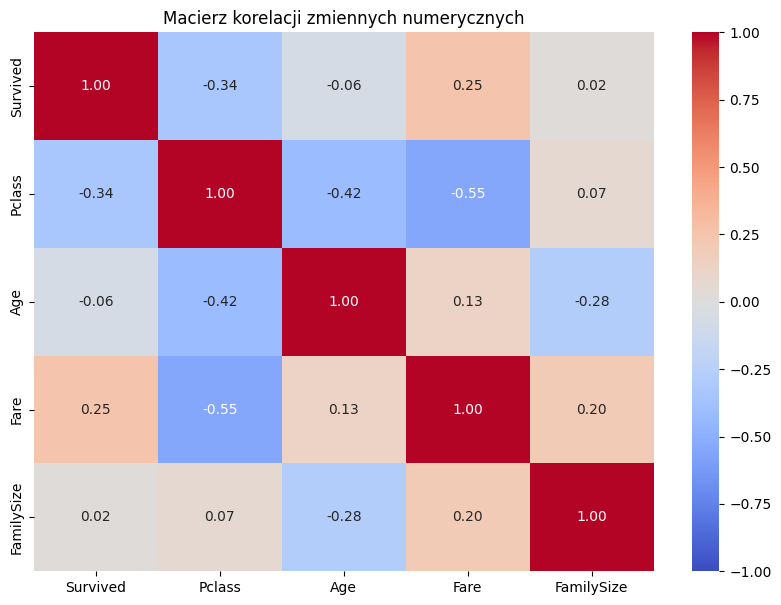

In [109]:
titanic_df['Survived'] = titanic_df['Survived'].astype(int)
titanic_df['Pclass'] = titanic_df['Pclass'].astype(int)

draw_numeric_heatmap()

Widać odwrotną korelację pomiędzy ceną biletu a klasą pasażerską, ale chyba nie warto nic z tym robić.

Teraz przejdźmy do zakodowania pozostałych zmiennych.

In [110]:
# płeć - zmienna binarna
titanic_df['Sex'] = titanic_df['Sex'].map({'female': 1, 'male': 0}).astype(int)

# one hot encoding bo to zmienne nominalne
titanic_encoded = pd.get_dummies(titanic_df, columns=['Embarked', 'Deck', 'Title'])

In [111]:
titanic_encoded.corr()['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex,0.543351
Title_Mrs,0.339040
Title_Miss,0.327093
Fare,0.254149
Deck_B,0.175095
Embarked_C,0.168240
Deck_D,0.150716
Deck_E,0.145321
Deck_C,0.114652


In [112]:
titanic_encoded.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,Embarked_C,Embarked_Q,Embarked_S,Deck_A,...,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,7.2500,1,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
2,1,1,1,38.0,71.2833,1,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,1,3,1,26.0,7.9250,0,False,False,True,False,...,False,False,False,False,True,False,True,False,False,False
4,1,1,1,35.0,53.1000,1,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
5,0,3,0,35.0,8.0500,0,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
